# Store Sales & Profit Analysis: Professional Data Storytelling Notebook

**Scenario:** A retail/e-commerce company wants to understand sales, profit, customer, region, product, and discount performance.

This notebook is designed as a **portfolio-ready analytics project**. It includes a synthetic CSV so it can run immediately, but the same template can be reused with a real business CSV.

## 1. Executive Summary

This section is intentionally placed first. In professional analytics, decision makers usually want the answer before the technical details. Run the notebook once, then update this section with the final findings.

**Business Questions**

1. Is the business growing?
2. Which categories and products drive profit?
3. Which regions and segments perform best?
4. Are discounts improving sales or destroying margin?
5. What should management do next?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_PATH = Path('synthetic_store_sales.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/store_sales_storytelling_project/synthetic_store_sales.csv')

df = pd.read_csv(DATA_PATH)
df.head()

,order_id,order_date,customer_name,segment,region,state,city,ship_mode,category,sub_category,product_name,quantity,sales,profit,discount,shipping_cost
0,ORD-2024-00001,2024-08-02,Customer 280,Consumer,West,New York,Albany,Standard Class,Technology,Copiers,Copiers Product 12,7,"3,863.74",697.86,0.20,206.25
1,ORD-2021-00002,2021-03-03,Customer 143,Consumer,East,Washington,Tacoma,Second Class,Technology,Accessories,Accessories Product 01,8,490.98,170.74,0.00,31.58
2,ORD-2024-00003,2024-11-30,Customer 136,Home Office,West,Illinois,Chicago,Standard Class,Furniture,Bookcases,Bookcases Product 06,3,386.63,-83.96,0.40,24.14
3,ORD-2023-00004,2023-02-15,Customer 024,Corporate,South,Illinois,Chicago,Standard Class,Technology,Copiers,Copiers Product 30,5,"4,742.33",726.51,0.15,309.43
4,ORD-2022-00005,2022-04-22,Customer 108,Corporate,West,Illinois,Chicago,Standard Class,Office Supplies,Appliances,Appliances Product 35,6,843.00,76.81,0.05,51.10


## 2. Data Dictionary

Expected CSV columns:

| Column | Meaning |
|---|---|
| order_id | Unique order identifier |
| order_date | Date of transaction |
| customer_name | Customer name or customer ID |
| segment | Customer segment |
| region | Sales region |
| state, city | Location |
| ship_mode | Delivery method |
| category | Main product category |
| sub_category | Product sub-category |
| product_name | Product label |
| quantity | Units sold |
| sales | Revenue after discount |
| profit | Net profit |
| discount | Discount rate, e.g. 0.2 = 20% |
| shipping_cost | Delivery/logistics cost |

In [2]:
# Standardize column names
df.columns = (df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_'))

required_columns = ['order_id','order_date','sales','profit','discount','quantity','category','sub_category','region','segment','customer_name','product_name']
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['quarter'] = df['order_date'].dt.quarter
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

df['profit_margin'] = np.where(df['sales'] != 0, df['profit'] / df['sales'] * 100, 0)
df['average_selling_price'] = np.where(df['quantity'] != 0, df['sales'] / df['quantity'], 0)
df.head()

,order_id,order_date,customer_name,segment,region,state,city,ship_mode,category,sub_category,product_name,quantity,sales,profit,discount,shipping_cost,year,month,month_name,quarter,year_month,profit_margin,average_selling_price
0,ORD-2024-00001,2024-08-02,Customer 280,Consumer,West,New York,Albany,Standard Class,Technology,Copiers,Copiers Product 12,7,"3,863.74",697.86,0.20,206.25,2024,8,August,3,2024-08,18.06,551.96
1,ORD-2021-00002,2021-03-03,Customer 143,Consumer,East,Washington,Tacoma,Second Class,Technology,Accessories,Accessories Product 01,8,490.98,170.74,0.00,31.58,2021,3,March,1,2021-03,34.78,61.37
2,ORD-2024-00003,2024-11-30,Customer 136,Home Office,West,Illinois,Chicago,Standard Class,Furniture,Bookcases,Bookcases Product 06,3,386.63,-83.96,0.40,24.14,2024,11,November,4,2024-11,-21.72,128.88
3,ORD-2023-00004,2023-02-15,Customer 024,Corporate,South,Illinois,Chicago,Standard Class,Technology,Copiers,Copiers Product 30,5,"4,742.33",726.51,0.15,309.43,2023,2,February,1,2023-02,15.32,948.47
4,ORD-2022-00005,2022-04-22,Customer 108,Corporate,West,Illinois,Chicago,Standard Class,Office Supplies,Appliances,Appliances Product 35,6,843.00,76.81,0.05,51.10,2022,4,April,2,2022-04,9.11,140.50


## 3. Data Quality Assessment

Professional notebooks should show whether the dataset is reliable before discussing business conclusions.

In [3]:
data_quality = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_percentage': df.isna().mean() * 100,
    'unique_values': df.nunique()
}).sort_values('missing_percentage', ascending=False)

duplicate_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count}')
data_quality

Duplicate rows found: 0


,missing_values,missing_percentage,unique_values
order_id,0,0.00,3500
sales,0,0.00,3436
profit_margin,0,0.00,3499
year_month,0,0.00,48
quarter,0,0.00,4
month_name,0,0.00,12
month,0,0.00,12
year,0,0.00,4
shipping_cost,0,0.00,2462
discount,0,0.00,8


In [4]:
# Remove exact duplicates if any
df = df.drop_duplicates().copy()

# Basic sanity checks
print('Date range:', df['order_date'].min(), 'to', df['order_date'].max())
print('Negative sales rows:', (df['sales'] < 0).sum())
print('Negative profit rows:', (df['profit'] < 0).sum())
print('Zero quantity rows:', (df['quantity'] == 0).sum())

Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00
Negative sales rows: 0
Negative profit rows: 911
Zero quantity rows: 0


## 4. KPI Dashboard

This section gives a board-level view of the business.

In [5]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_name'].nunique()
avg_profit_margin = total_profit / total_sales * 100
avg_order_value = total_sales / total_orders

kpi_summary = pd.DataFrame({
    'KPI': ['Total Sales','Total Profit','Total Orders','Total Customers','Average Profit Margin %','Average Order Value'],
    'Value': [total_sales,total_profit,total_orders,total_customers,avg_profit_margin,avg_order_value]
})
kpi_summary

,KPI,Value
0,Total Sales,"3,251,921.50"
1,Total Profit,"279,629.55"
2,Total Orders,"3,500.00"
3,Total Customers,300.00
4,Average Profit Margin %,8.60
5,Average Order Value,929.12


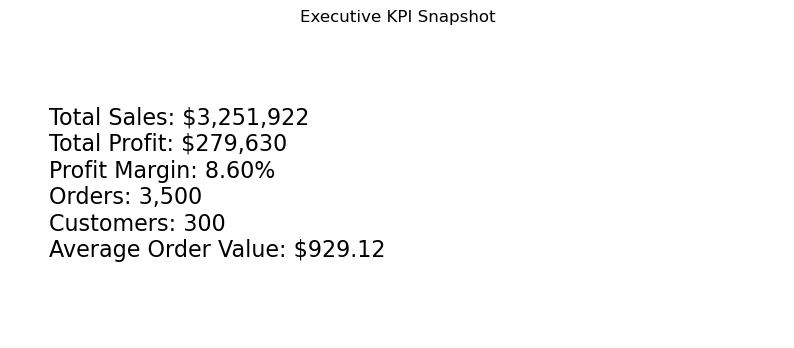

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
summary_text = (
    f'Total Sales: ${total_sales:,.0f}\n'
    f'Total Profit: ${total_profit:,.0f}\n'
    f'Profit Margin: {avg_profit_margin:.2f}%\n'
    f'Orders: {total_orders:,}\n'
    f'Customers: {total_customers:,}\n'
    f'Average Order Value: ${avg_order_value:,.2f}'
)
ax.text(0.05, 0.5, summary_text, fontsize=16, va='center')
plt.title('Executive KPI Snapshot')
plt.show()

## 5. Revenue Story: Is the Business Growing?

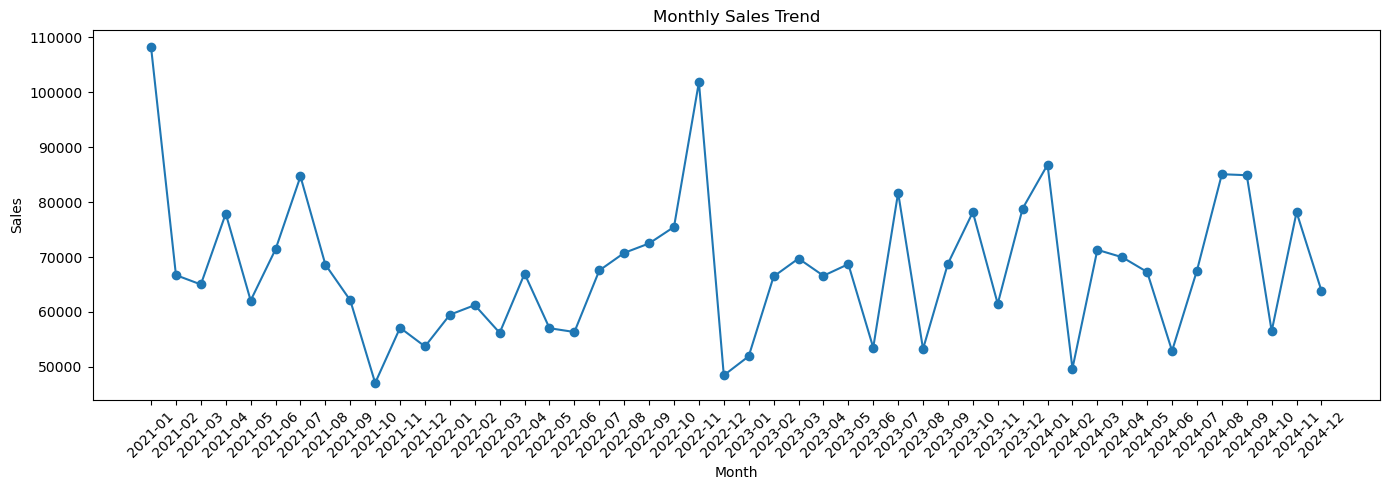

In [7]:
monthly_sales = df.groupby('year_month', as_index=False)['sales'].sum()
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['sales'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

In [8]:
yearly = df.groupby('year', as_index=False).agg(sales=('sales','sum'), profit=('profit','sum'))
yearly['sales_growth_%'] = yearly['sales'].pct_change() * 100
yearly['profit_growth_%'] = yearly['profit'].pct_change() * 100
yearly['profit_margin_%'] = yearly['profit'] / yearly['sales'] * 100
yearly

,year,sales,profit,sales_growth_%,profit_growth_%,profit_margin_%
0,2021,"824,718.01","65,198.58",NaN,NaN,7.91
1,2022,"793,932.39","66,160.40",-3.73,1.48,8.33
2,2023,"799,225.64","62,489.40",0.67,-5.55,7.82
3,2024,"834,045.46","85,781.17",4.36,37.27,10.28


## 6. Profitability Story: Revenue vs Profit

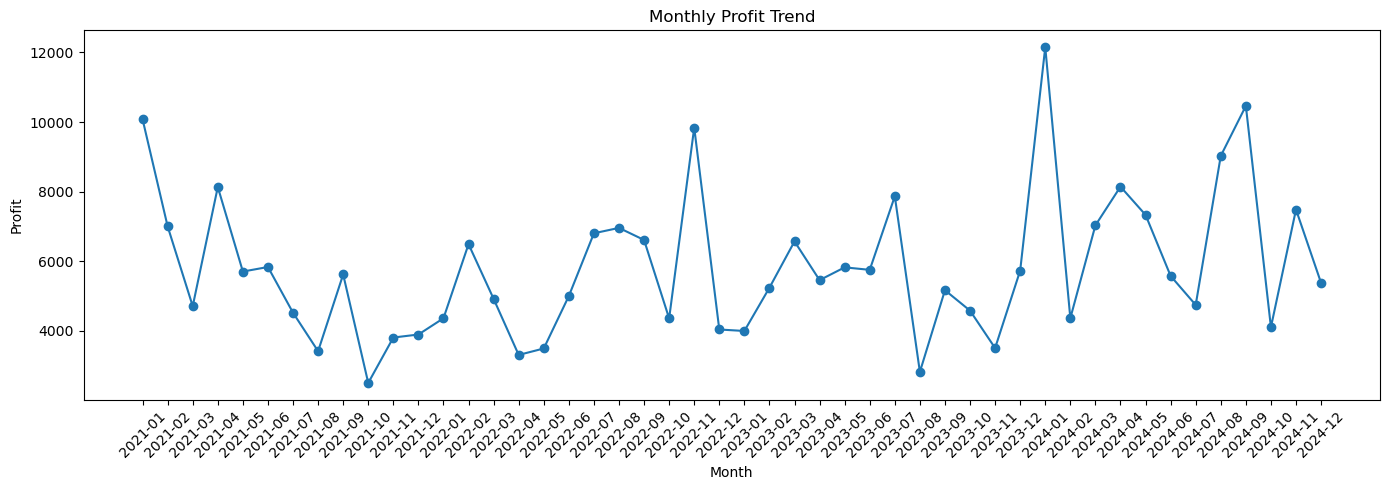

,year_month,sales,profit,profit_margin_%
43,2024-08,"85,083.35","9,025.76",10.61
44,2024-09,"84,901.49","10,462.32",12.32
45,2024-10,"56,505.62","4,103.05",7.26
46,2024-11,"78,162.83","7,484.17",9.58
47,2024-12,"63,841.43","5,375.19",8.42


In [9]:
monthly_profit = df.groupby('year_month', as_index=False).agg(sales=('sales','sum'), profit=('profit','sum'))
monthly_profit['profit_margin_%'] = monthly_profit['profit'] / monthly_profit['sales'] * 100

plt.figure(figsize=(14, 5))
plt.plot(monthly_profit['year_month'], monthly_profit['profit'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

monthly_profit.tail()

## 7. Category and Sub-Category Performance

In [10]:
category_perf = df.groupby('category', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), quantity=('quantity','sum'), orders=('order_id','nunique')
)
category_perf['profit_margin_%'] = category_perf['profit'] / category_perf['sales'] * 100
category_perf.sort_values('profit', ascending=False)

,category,sales,profit,quantity,orders,profit_margin_%
2,Technology,"2,208,109.57","287,109.29",5011,1115,13.00
1,Office Supplies,"288,080.48","18,961.44",6344,1406,6.58
0,Furniture,"755,731.45","-26,441.18",4591,979,-3.50


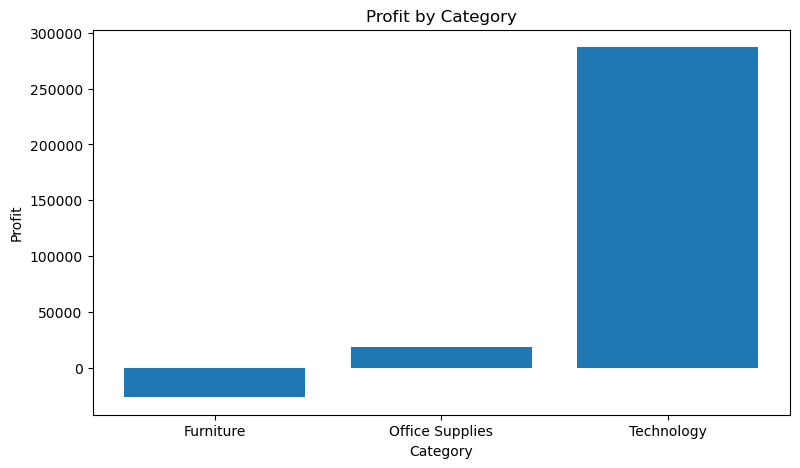

In [11]:
plt.figure(figsize=(9, 5))
plt.bar(category_perf['category'], category_perf['profit'])
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

In [12]:
subcat_perf = df.groupby('sub_category', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), quantity=('quantity','sum'), avg_discount=('discount','mean')
)
subcat_perf['profit_margin_%'] = subcat_perf['profit'] / subcat_perf['sales'] * 100
subcat_perf.sort_values('profit').head(10)

,sub_category,sales,profit,quantity,avg_discount,profit_margin_%
13,Tables,"301,563.73","-26,541.27",1106,0.23,-8.80
4,Bookcases,"203,079.66","-18,756.05",1257,0.25,-9.24
8,Labels,"11,678.70","1,874.42",1103,0.12,16.05
10,Paper,"15,283.94","2,804.94",965,0.12,18.35
1,Appliances,"127,582.88","2,822.24",1031,0.14,2.21
2,Art,"21,471.16","3,156.36",1114,0.12,14.70
3,Binders,"27,337.40","3,164.20",1109,0.13,11.57
12,Storage,"84,726.40","5,139.28",1022,0.12,6.07
7,Furnishings,"74,622.62","8,126.88",1107,0.11,10.89
5,Chairs,"176,465.44","10,729.26",1121,0.13,6.08


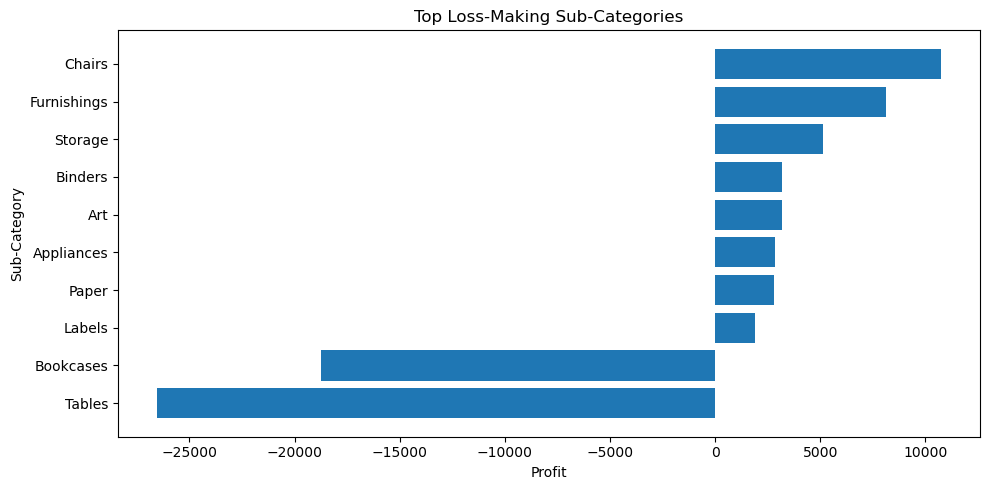

In [13]:
top_loss = subcat_perf.sort_values('profit').head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_loss['sub_category'], top_loss['profit'])
plt.title('Top Loss-Making Sub-Categories')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

## 8. Regional Performance

In [14]:
region_perf = df.groupby('region', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), quantity=('quantity','sum'), orders=('order_id','nunique')
)
region_perf['profit_margin_%'] = region_perf['profit'] / region_perf['sales'] * 100
region_perf.sort_values('profit', ascending=False)

,region,sales,profit,quantity,orders,profit_margin_%
3,West,"1,083,994.97","119,900.21",5356,1170,11.06
1,East,"878,022.07","87,300.75",4244,902,9.94
0,Central,"670,037.25","36,393.94",3536,785,5.43
2,South,"619,867.21","36,034.65",2810,643,5.81


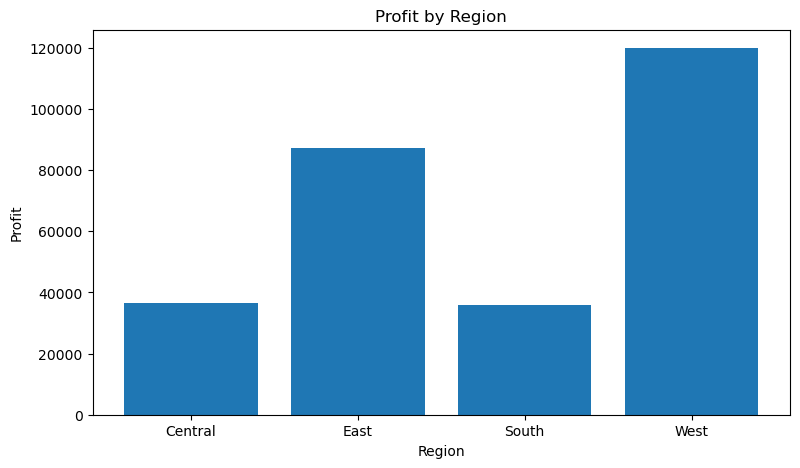

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(region_perf['region'], region_perf['profit'])
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

## 9. Customer Segment and Customer Value

In [16]:
segment_perf = df.groupby('segment', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), customers=('customer_name','nunique'), orders=('order_id','nunique')
)
segment_perf['profit_margin_%'] = segment_perf['profit'] / segment_perf['sales'] * 100
segment_perf.sort_values('profit', ascending=False)

,segment,sales,profit,customers,orders,profit_margin_%
0,Consumer,"1,679,075.94","147,438.71",299,1792,8.78
1,Corporate,"986,790.33","78,909.50",289,1103,8.00
2,Home Office,"586,055.23","53,281.34",260,605,9.09


In [17]:
top_customers = df.groupby('customer_name', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), orders=('order_id','nunique')
)
top_customers['profit_margin_%'] = top_customers['profit'] / top_customers['sales'] * 100
top_customers.sort_values('profit', ascending=False).head(20)

,customer_name,sales,profit,orders,profit_margin_%
220,Customer 221,"24,794.15","4,392.21",9,17.71
27,Customer 028,"22,265.86","4,169.25",14,18.72
94,Customer 095,"20,931.33","4,097.68",17,19.58
102,Customer 103,"23,551.79","4,085.48",16,17.35
2,Customer 003,"20,641.57","3,904.76",9,18.92
51,Customer 052,"35,825.29","3,798.04",24,10.60
30,Customer 031,"21,041.50","3,594.68",15,17.08
125,Customer 126,"29,738.15","3,292.69",24,11.07
112,Customer 113,"19,146.74","3,241.36",10,16.93
255,Customer 256,"15,888.20","3,140.98",18,19.77


## 10. Product Intelligence

In [18]:
product_perf = df.groupby('product_name', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), quantity=('quantity','sum'), avg_discount=('discount','mean')
)
product_perf['profit_margin_%'] = product_perf['profit'] / product_perf['sales'] * 100

def classify_product(row):
    if row['profit'] > 0 and row['profit_margin_%'] >= 15:
        return 'High Profit Product'
    if row['profit'] > 0 and row['profit_margin_%'] < 15:
        return 'Low Margin Product'
    if row['profit'] < 0:
        return 'Loss Making Product'
    return 'Neutral Product'

product_perf['product_status'] = product_perf.apply(classify_product, axis=1)
product_perf['product_status'].value_counts()

product_status
Low Margin Product     514
High Profit Product    340
Loss Making Product    218
Name: count, dtype: int64

In [19]:
product_perf.sort_values('profit').head(20)

,product_name,sales,profit,quantity,avg_discount,profit_margin_%,product_status
1057,Tables Product 66,"5,313.79","-1,032.15",25,0.34,-19.42,Loss Making Product
1000,Tables Product 05,"9,368.93","-1,019.59",36,0.31,-10.88,Loss Making Product
1042,Tables Product 49,"6,977.88",-958.46,29,0.34,-13.74,Loss Making Product
333,Bookcases Product 26,"4,895.06",-941.29,28,0.34,-19.23,Loss Making Product
1002,Tables Product 07,"4,732.13",-917.17,17,0.26,-19.38,Loss Making Product
1068,Tables Product 77,"7,912.22",-800.50,27,0.28,-10.12,Loss Making Product
345,Bookcases Product 38,"3,538.76",-789.56,23,0.34,-22.31,Loss Making Product
1009,Tables Product 16,"4,398.61",-743.18,15,0.29,-16.90,Loss Making Product
1047,Tables Product 54,"2,899.55",-724.61,13,0.40,-24.99,Loss Making Product
359,Bookcases Product 52,"4,959.57",-707.05,35,0.33,-14.26,Loss Making Product


## 11. Discount Impact Analysis

This is one of the most important business sections. Sales can increase while profit decreases if discounts are too aggressive.

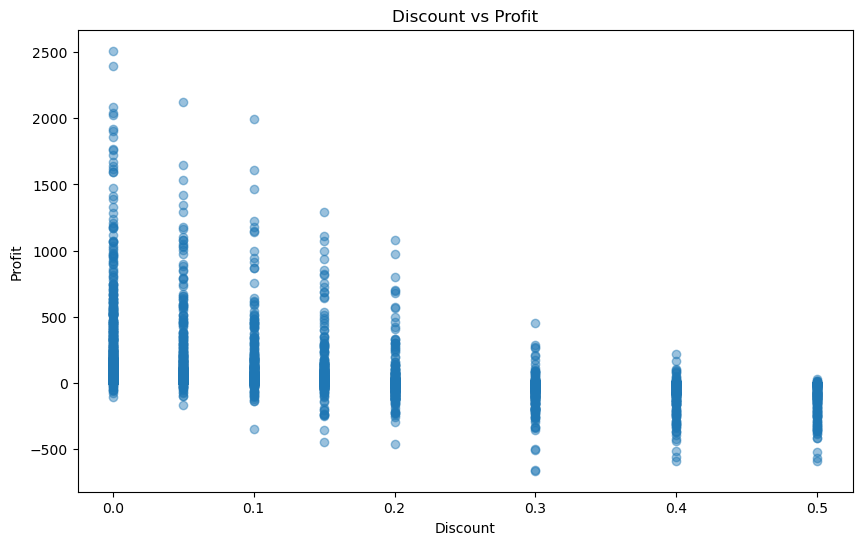

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['discount'], df['profit'], alpha=0.45)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

In [21]:
df['discount_range'] = pd.cut(
    df['discount'],
    bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['No Discount','0-10%','10-20%','20-30%','30-50%','50%+']
)

discount_analysis = df.groupby('discount_range', observed=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), orders=('order_id','nunique')
).reset_index()
discount_analysis['profit_margin_%'] = discount_analysis['profit'] / discount_analysis['sales'] * 100
discount_analysis

,discount_range,sales,profit,orders,profit_margin_%
0,No Discount,"1,032,103.59","176,306.06",975,17.08
1,0-10%,"972,043.02","122,229.88",977,12.57
2,10-20%,"764,240.65","35,320.29",849,4.62
3,20-30%,"234,068.10","-14,742.54",294,-6.30
4,30-50%,"249,466.14","-39,484.14",405,-15.83
5,50%+,0.00,0.00,0,NaN


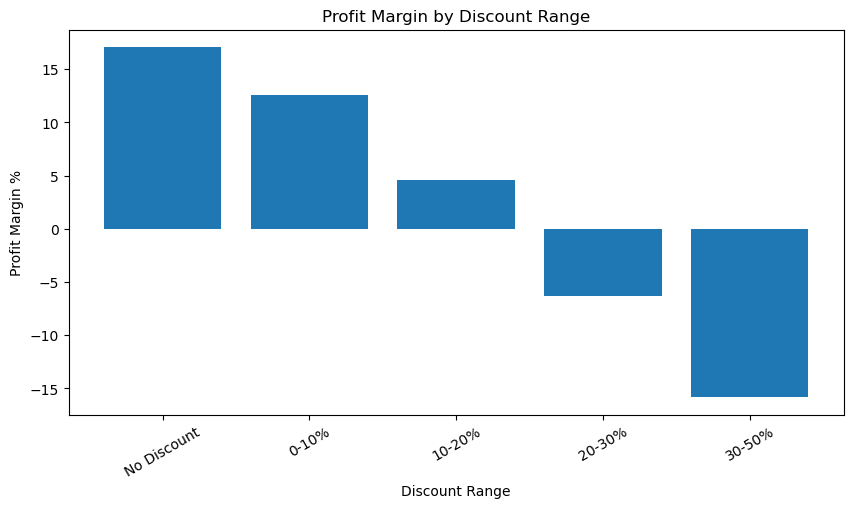

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(discount_analysis['discount_range'].astype(str), discount_analysis['profit_margin_%'])
plt.title('Profit Margin by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=30)
plt.show()

## 12. Root Cause Analysis

In [23]:
loss_data = df[df['profit'] < 0].copy()
loss_summary = loss_data.groupby(['category','sub_category','region'], as_index=False).agg(
    loss_amount=('profit','sum'), sales=('sales','sum'), avg_discount=('discount','mean'), orders=('order_id','nunique')
)
loss_summary.sort_values('loss_amount').head(20)

,category,sub_category,region,loss_amount,sales,avg_discount,orders
15,Furniture,Tables,West,"-9,493.63","91,685.75",0.27,76
12,Furniture,Tables,Central,"-7,823.30","45,154.00",0.31,40
13,Furniture,Tables,East,"-7,817.77","64,892.91",0.25,48
0,Furniture,Bookcases,Central,"-6,051.88","39,049.70",0.28,55
3,Furniture,Bookcases,West,"-5,797.49","40,775.63",0.34,56
14,Furniture,Tables,South,"-5,428.66","27,507.38",0.33,31
1,Furniture,Bookcases,East,"-4,982.63","39,757.89",0.30,51
2,Furniture,Bookcases,South,"-4,579.32","30,295.50",0.29,46
47,Technology,Machines,Central,"-4,140.08","65,150.07",0.23,28
48,Technology,Machines,East,"-2,697.02","31,767.54",0.32,15


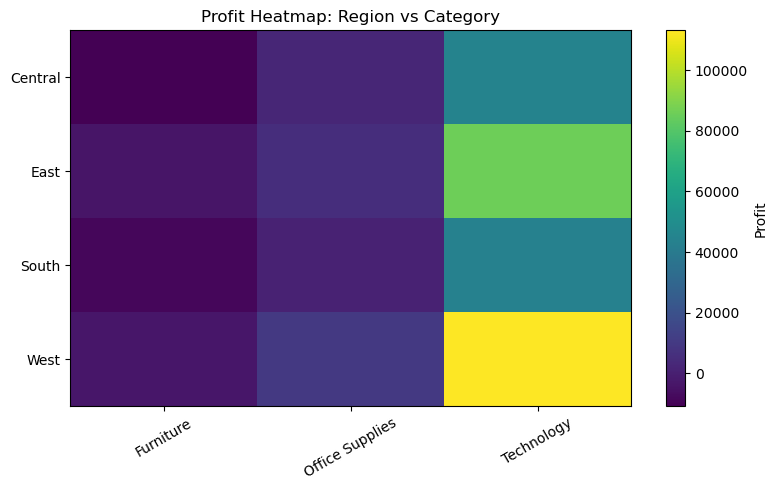

category,Furniture,Office Supplies,Technology
region,,,
Central,"-10,865.99","2,661.28","44,598.65"
East,"-3,625.09","5,311.80","85,614.04"
South,"-8,821.46","1,114.18","43,741.93"
West,"-3,128.64","9,874.18","113,154.67"


In [24]:
region_category_matrix = df.pivot_table(index='region', columns='category', values='profit', aggfunc='sum')
plt.figure(figsize=(8, 5))
plt.imshow(region_category_matrix, aspect='auto')
plt.colorbar(label='Profit')
plt.xticks(range(len(region_category_matrix.columns)), region_category_matrix.columns, rotation=30)
plt.yticks(range(len(region_category_matrix.index)), region_category_matrix.index)
plt.title('Profit Heatmap: Region vs Category')
plt.tight_layout()
plt.show()
region_category_matrix

## 13. Recommendation Engine

This section converts analytics into management actions.

In [25]:
recommendations = []

if avg_profit_margin < 10:
    recommendations.append('Overall profit margin is below 10%; review pricing, cost, and discount policy.')

high_discount_loss = df[(df['discount'] > 0.2) & (df['profit'] < 0)]
if len(high_discount_loss) > 0:
    recommendations.append('Discounts above 20% are linked with loss-making orders; set approval rules for high discounts.')

for _, row in category_perf[category_perf['profit'] < 0].iterrows():
    recommendations.append(f"Category '{row['category']}' is loss-making; review pricing and supplier cost.")

for _, row in product_perf.sort_values('profit').head(5).iterrows():
    recommendations.append(f"Review/reprice product '{row['product_name']}' because it generated ${row['profit']:,.0f} profit.")

for i, rec in enumerate(recommendations, 1):
    print(f'{i}. {rec}')

1. Overall profit margin is below 10%; review pricing, cost, and discount policy.
2. Discounts above 20% are linked with loss-making orders; set approval rules for high discounts.
3. Category 'Furniture' is loss-making; review pricing and supplier cost.
4. Review/reprice product 'Tables Product 66' because it generated $-1,032 profit.
5. Review/reprice product 'Tables Product 05' because it generated $-1,020 profit.
6. Review/reprice product 'Tables Product 49' because it generated $-958 profit.
7. Review/reprice product 'Bookcases Product 26' because it generated $-941 profit.
8. Review/reprice product 'Tables Product 07' because it generated $-917 profit.


## 14. Optional Sales Forecasting

This creates a simple 6-month sales forecast. For production, compare multiple models and validate error metrics.

/Users/jerin/miniconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


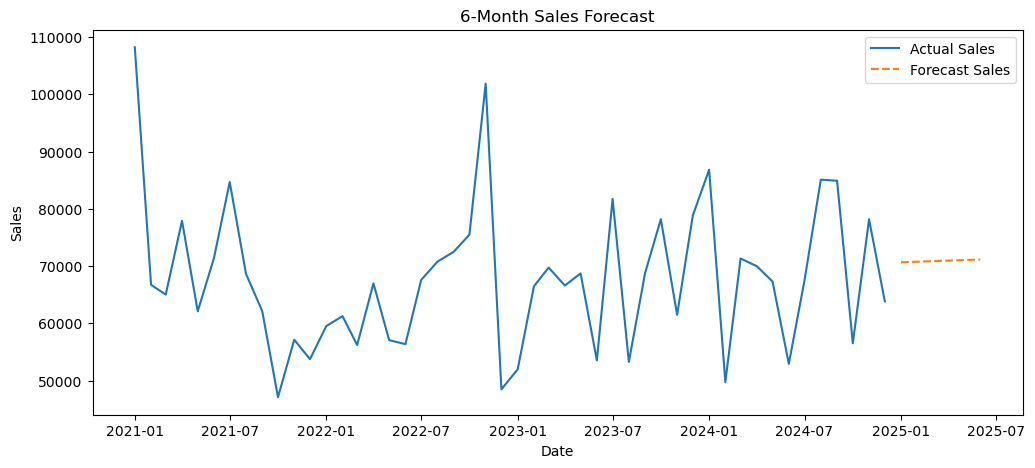

,forecast_sales
2025-01-01,"70,654.85"
2025-02-01,"70,751.29"
2025-03-01,"70,847.74"
2025-04-01,"70,944.18"
2025-05-01,"71,040.62"
2025-06-01,"71,137.06"


In [26]:
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    forecast_df = monthly_sales.copy()
    forecast_df['year_month'] = pd.to_datetime(forecast_df['year_month'])
    forecast_df = forecast_df.set_index('year_month').asfreq('MS')

    model = ExponentialSmoothing(forecast_df['sales'], trend='add', seasonal=None)
    fit_model = model.fit()
    forecast = fit_model.forecast(6)

    plt.figure(figsize=(12, 5))
    plt.plot(forecast_df.index, forecast_df['sales'], label='Actual Sales')
    plt.plot(forecast.index, forecast, linestyle='--', label='Forecast Sales')
    plt.title('6-Month Sales Forecast')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()
    display(forecast.to_frame('forecast_sales'))
except Exception as e:
    print('Forecasting skipped. Install statsmodels if needed. Error:', e)

## 15. Final Executive Report

In [27]:
best_category = category_perf.sort_values('profit', ascending=False).iloc[0]['category']
worst_category = category_perf.sort_values('profit').iloc[0]['category']
best_region = region_perf.sort_values('profit', ascending=False).iloc[0]['region']
worst_region = region_perf.sort_values('profit').iloc[0]['region']

print('FINAL EXECUTIVE REPORT')
print('=' * 80)
print(f'Total Sales: ${total_sales:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Profit Margin: {avg_profit_margin:.2f}%')
print(f'Total Orders: {total_orders:,}')
print(f'Total Customers: {total_customers:,}')
print(f'Average Order Value: ${avg_order_value:,.2f}')
print()
print(f'Best Category: {best_category}')
print(f'Weakest Category: {worst_category}')
print(f'Best Region: {best_region}')
print(f'Weakest Region: {worst_region}')
print()
print('Recommended Actions:')
for i, rec in enumerate(recommendations[:10], 1):
    print(f'{i}. {rec}')

FINAL EXECUTIVE REPORT
Total Sales: $3,251,921.50
Total Profit: $279,629.55
Profit Margin: 8.60%
Total Orders: 3,500
Total Customers: 300
Average Order Value: $929.12

Best Category: Technology
Weakest Category: Furniture
Best Region: West
Weakest Region: South

Recommended Actions:
1. Overall profit margin is below 10%; review pricing, cost, and discount policy.
2. Discounts above 20% are linked with loss-making orders; set approval rules for high discounts.
3. Category 'Furniture' is loss-making; review pricing and supplier cost.
4. Review/reprice product 'Tables Product 66' because it generated $-1,032 profit.
5. Review/reprice product 'Tables Product 05' because it generated $-1,020 profit.
6. Review/reprice product 'Tables Product 49' because it generated $-958 profit.
7. Review/reprice product 'Bookcases Product 26' because it generated $-941 profit.
8. Review/reprice product 'Tables Product 07' because it generated $-917 profit.


## 16. Final Business Conclusion Template

The company has healthy sales activity, but profitability varies significantly by category, sub-category, region, product, and discount level. The main issue is not only revenue generation; the key business challenge is profit leakage.

**Key conclusions:**

1. Track profit margin, not only sales.
2. Investigate loss-making products and sub-categories.
3. Limit high discounts unless they are strategically justified.
4. Replicate the strategy of the best-performing region.
5. Expand high-margin products and reduce exposure to low-margin products.

**Next product analytics improvements:**

- Add customer lifetime value.
- Add cohort retention.
- Add inventory and supplier cost data.
- Add marketing channel attribution.
- Build a Streamlit dashboard from this notebook.